In [11]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import kagglehub
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from tqdm import tqdm
import shutil


In [ ]:
# Download latest version of the data-set from kaggle
path = kagglehub.dataset_download("slavkoprytula/aquarium-data-cots")
print("Downloaded to:", path)

shutil.copytree(path, "/content/aquarium-data", dirs_exist_ok=True)
DATA_ROOT = "/content/aquarium-data/aquarium_pretrain"


In [13]:

SPLIT = "train"

IMG_DIR = os.path.join(DATA_ROOT, SPLIT, "images")
LBL_DIR = os.path.join(DATA_ROOT, SPLIT, "labels")

CLASS_NAMES = ["fish", "jellyfish", "penguin", "shark", "puffin", "stingray", "starfish"]

def read_label(txt_path):
    out = []
    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                continue
            cls_id = int(float(parts[0]))
            cx, cy, w, h = map(float, parts[1:])
            out.append((cls_id, cx, cy, w, h))
    return out

def convert_coords(txt_path, img_w, img_h):
    # (cls_id, cx, cy, w, h)
    boxes = []
    labels = []

    out = read_label(txt_path)  # list of tuples
    for (cls_id, cx, cy, w, h) in out:
        x1 = (cx - w/2) * img_w
        y1 = (cy - h/2) * img_h
        x2 = (cx + w/2) * img_w
        y2 = (cy + h/2) * img_h

        boxes.append([x1, y1, x2, y2])
        labels.append(cls_id)

    return boxes, labels

image_files = [f for f in os.listdir(IMG_DIR) if f.endswith((".jpg",".png",".jpeg"))]



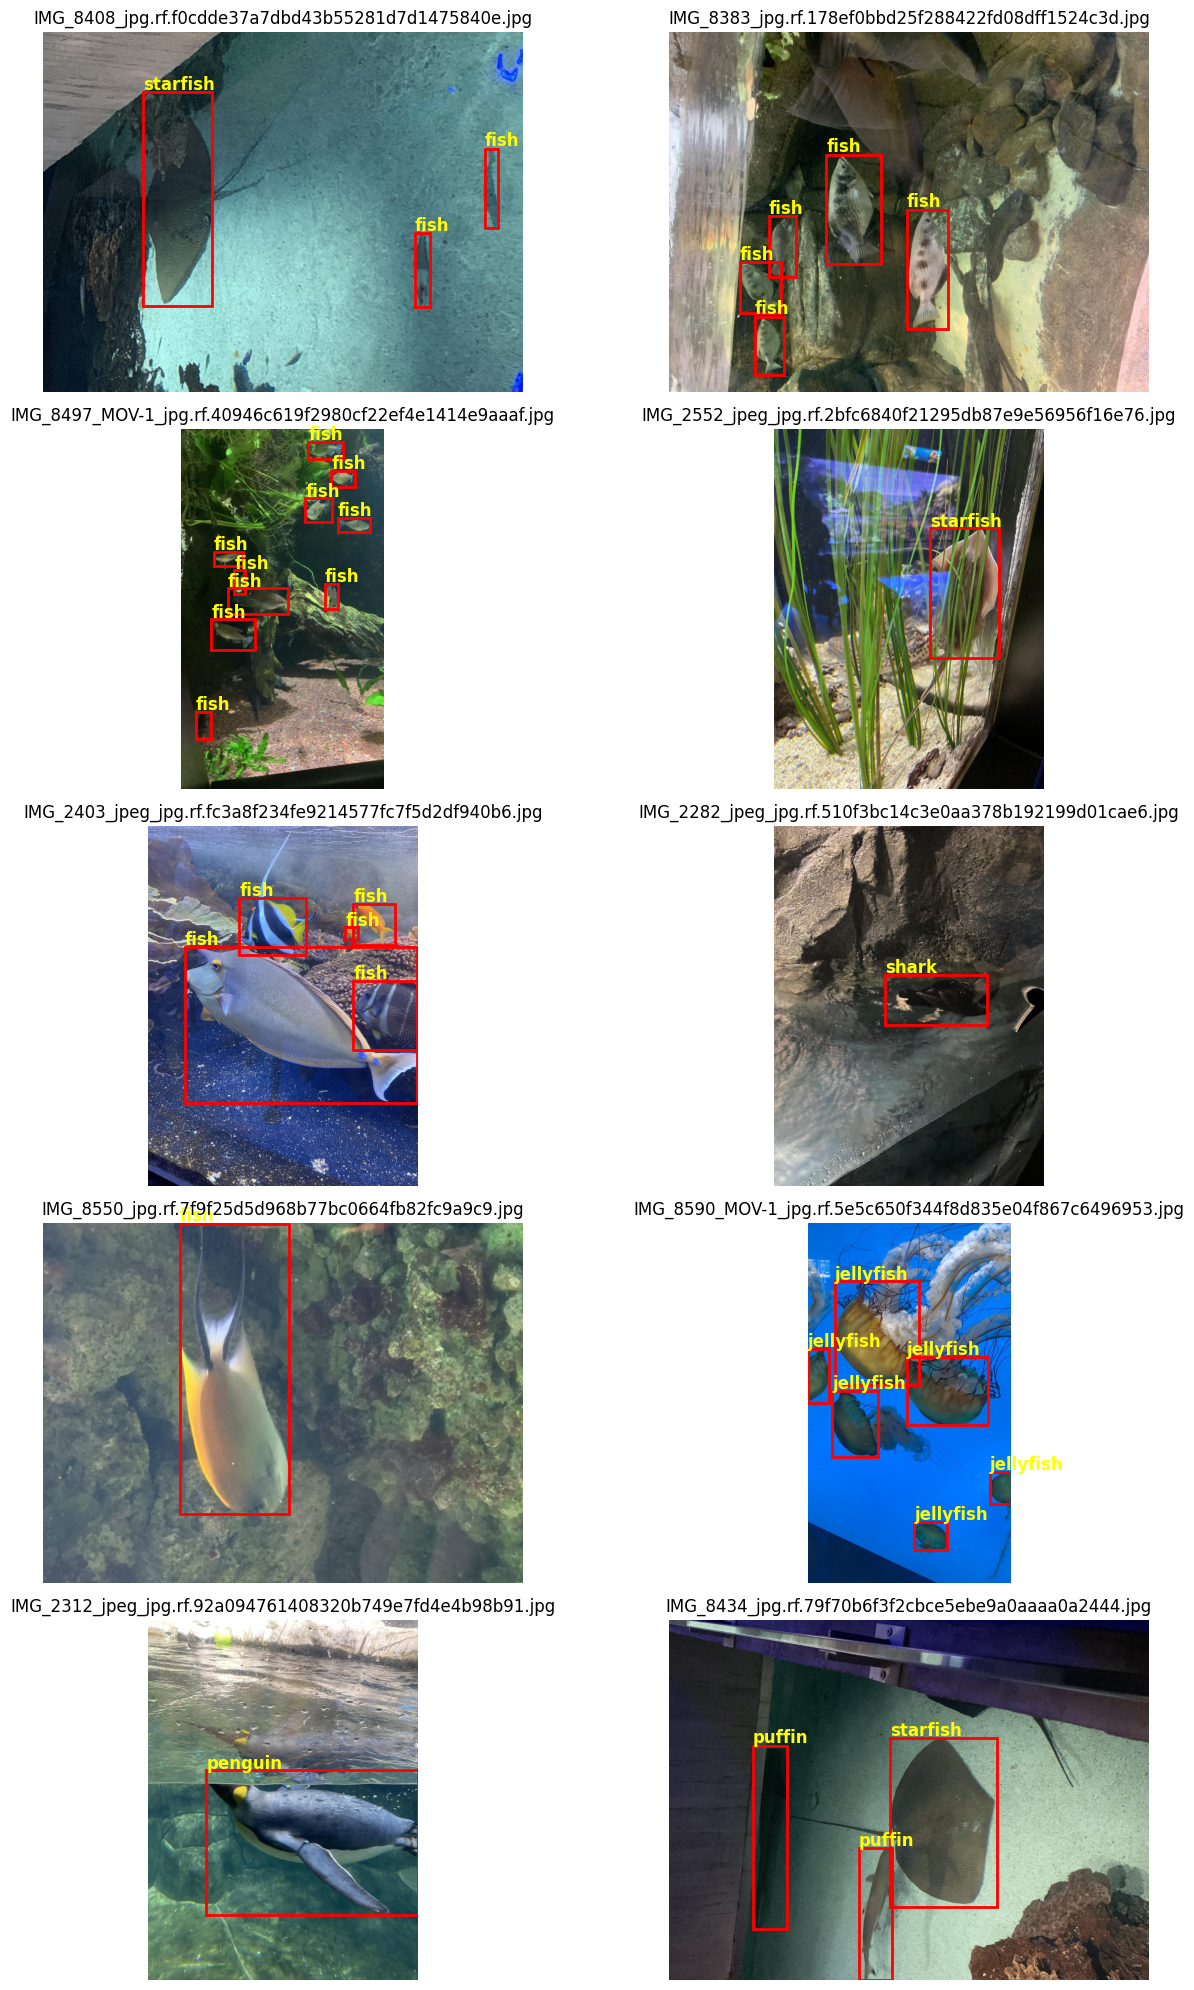

In [14]:
# Show random images from the data-set with thier Bounding Box
sample_imgs = random.sample(image_files, 10)

plt.figure(figsize=(14, 20))

for i, img_name in enumerate(sample_imgs):
    img_path = os.path.join(IMG_DIR, img_name)
    lbl_path = os.path.join(LBL_DIR, os.path.splitext(img_name)[0] + ".txt")

    img = Image.open(img_path).convert("RGB")
    img_w, img_h = img.size

    plt.subplot(5, 2, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)

    if os.path.exists(lbl_path):
        boxes, labels = convert_coords(lbl_path, img_w, img_h)

        for (x1, y1, x2, y2), cls_id in zip(boxes, labels):
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            plt.gca().add_patch(rect)

            cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
            plt.text(x1, y1-5, cls_name, color="yellow", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()

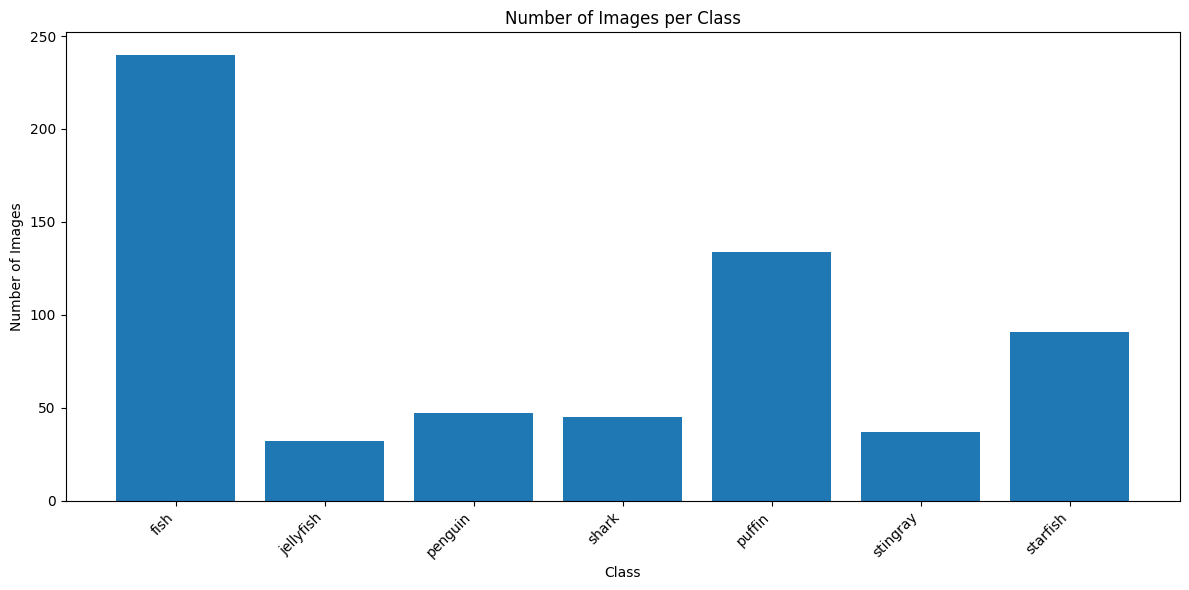

In [15]:
# Number of images in each class( an image can belong to more than one class)
images_per_class = defaultdict(set)

for img_name in os.listdir(IMG_DIR):
    if not img_name.endswith((".jpg",".png",".jpeg")):
        continue

    label_path = os.path.join(LBL_DIR, os.path.splitext(img_name)[0] + ".txt")
    if not os.path.exists(label_path):
        continue

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls_id = int(line.split()[0])
        images_per_class[cls_id].add(img_name)

cls_ids = sorted(images_per_class.keys())
counts = [len(images_per_class[c]) for c in cls_ids]
names = [CLASS_NAMES[c] for c in cls_ids]

plt.figure(figsize=(12, 6))
plt.bar(names, counts)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.title("Number of Images per Class")
plt.tight_layout()
plt.show()


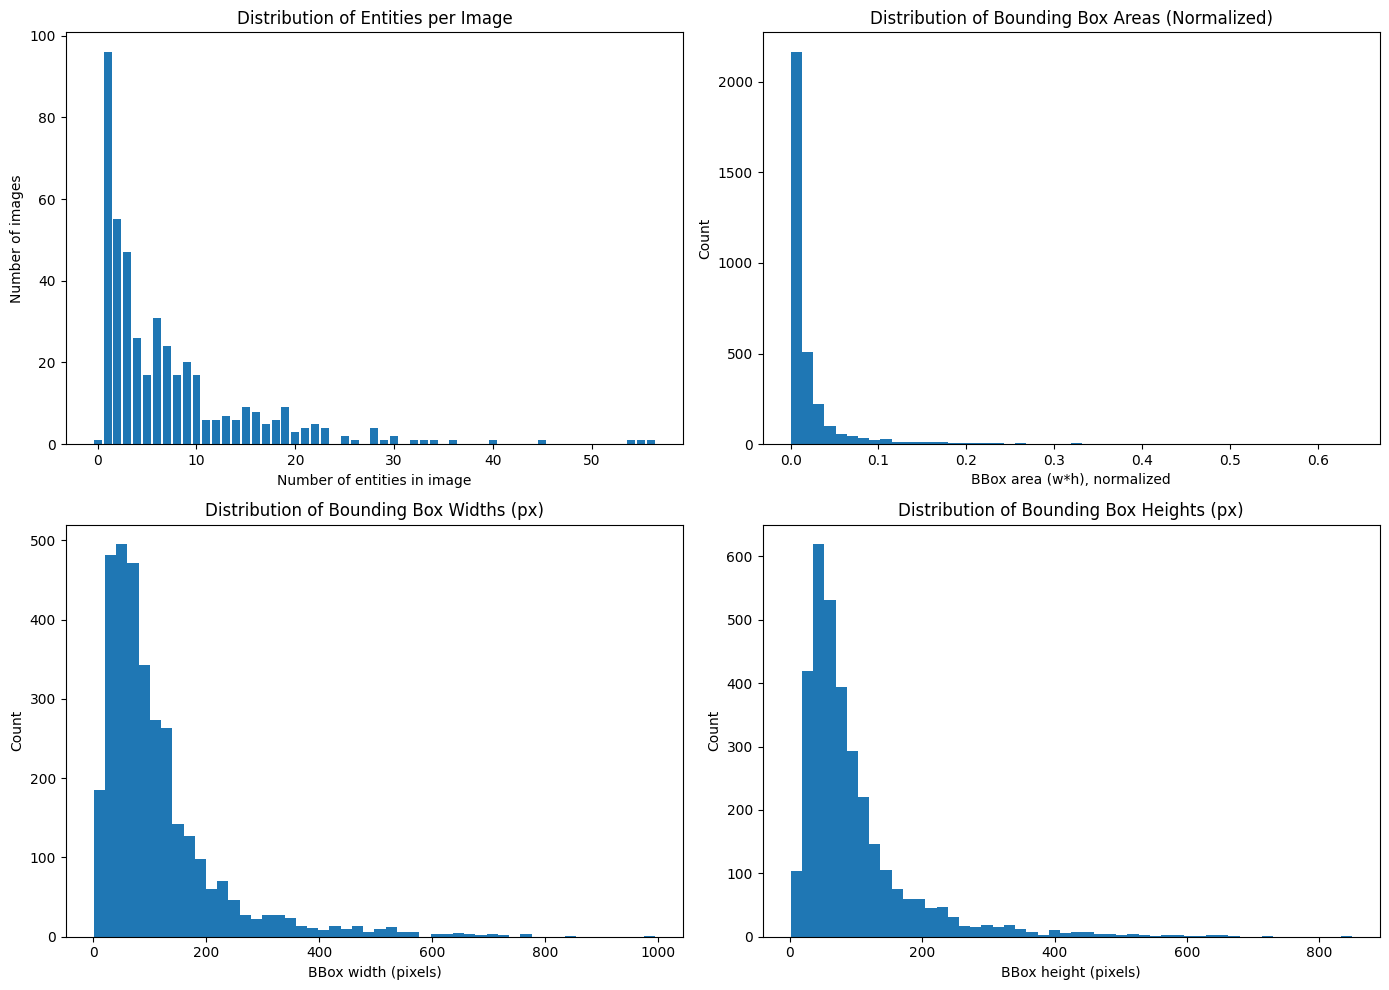

In [16]:
# EDA
entities_per_image = []
box_area_propor = []
box_w_px = []
box_h_px = []

for img_name in image_files:
    img_path = os.path.join(IMG_DIR, img_name)
    if not os.path.exists(img_path):
        continue

    lbl_path = os.path.join(LBL_DIR, os.path.splitext(img_name)[0] + ".txt")
    if not os.path.exists(lbl_path):
        continue

    out = read_label(lbl_path)
    entities_per_image.append(len(out))

    with Image.open(img_path) as im:
        img_w, img_h =  im.size

    for (cls_id, cx, cy, w, h) in out:
        box_area_propor.append(w * h)
        box_w_px.append(w * img_w)
        box_h_px.append(h * img_h)


plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
freq = Counter(entities_per_image)
plt.bar(sorted(freq.keys()), [freq[k] for k in sorted(freq.keys())])
plt.xlabel("Number of entities in image")
plt.ylabel("Number of images")
plt.title("Distribution of Entities per Image")

plt.subplot(2, 2, 2)
plt.hist(box_area_propor, bins=50)
plt.xlabel("BBox area (w*h), normalized")
plt.ylabel("Count")
plt.title("Distribution of Bounding Box Areas (Normalized)")

plt.subplot(2, 2, 3)
plt.hist(box_w_px, bins=50)
plt.xlabel("BBox width (pixels)")
plt.ylabel("Count")
plt.title("Distribution of Bounding Box Widths (px)")

plt.subplot(2, 2, 4)
plt.hist(box_h_px, bins=50)
plt.xlabel("BBox height (pixels)")
plt.ylabel("Count")
plt.title("Distribution of Bounding Box Heights (px)")

plt.tight_layout()
plt.show()


In [17]:
# Preprocessing
def compute_mean_std(image_files):
    mean = np.zeros(3)
    std = np.zeros(3)
    total_pixels = 0

    arrays = []

    for fname in image_files:
        img = Image.open(os.path.join(IMG_DIR, fname)).convert("RGB")
        arr = np.array(img).astype(np.float32) / 255.0
        arrays.append(arr)

        total_pixels += arr.shape[0] * arr.shape[1]
        mean += arr.sum(axis=(0, 1))

    mean /= total_pixels

    for arr in arrays:
        std += ((arr - mean) ** 2).sum(axis=(0, 1))

    std = np.sqrt(std / total_pixels)

    return mean, std


MEAN, STD = compute_mean_std(image_files)
print("Mean: ", MEAN)
print("Std: ", STD)

def gray_white_balance(img_rgb: Image.Image) -> Image.Image:
    arr = np.asarray(img_rgb).astype(np.float32)
    r_mean = arr[:, :, 0].mean()
    g_mean = arr[:, :, 1].mean()
    b_mean = arr[:, :, 2].mean()
    gray = (r_mean + g_mean + b_mean) / 3.0

    arr[:, :, 0] *= gray / (r_mean + 1e-6)
    arr[:, :, 1] *= gray / (g_mean + 1e-6)
    arr[:, :, 2] *= gray / (b_mean + 1e-6)

    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr, mode="RGB")

def processing(image_files, target_size=(640, 640)):
    images = []
    names = []

    mean = np.array(MEAN, dtype=np.float32)
    std = np.array(STD, dtype=np.float32)

    for fname in tqdm(image_files, desc="Loading + preprocessing"):
        path = os.path.join(IMG_DIR, fname)

        try:
            # Skip corrupt images
            with Image.open(path) as im:
                im.verify()
            # Color changing
            img = Image.open(path).convert("RGB")
            img = gray_white_balance(img)
            # Padding
            img.thumbnail(target_size, resample=Image.Resampling.BILINEAR)
            canvas = Image.new("RGB", target_size, (114, 114, 114))
            x = (target_size[0] - img.size[0]) // 2
            y = (target_size[1] - img.size[1]) // 2
            canvas.paste(img, (x, y))
            img = canvas
            # Normalizing
            arr = np.asarray(img)
            arr = arr.astype(np.float32) / 255.0
            arr = (arr - mean) / std

            images.append(arr)
            names.append(fname)

        except Exception as e:
            print(f"Error processing {fname}: {e}")
            continue

    return np.stack(images, axis=0) if images else np.empty((0, target_size[1], target_size[0], 3)), names





Mean:  [0.29001335 0.35291484 0.43819457]
Std:  [0.23016101 0.22007963 0.23189242]


Loading + preprocessing:   0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipython-input-2753674071.py:43: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGB")
Loading + preprocessing: 100%|██████████| 10/10 [00:00<00:00, 42.02it/s]


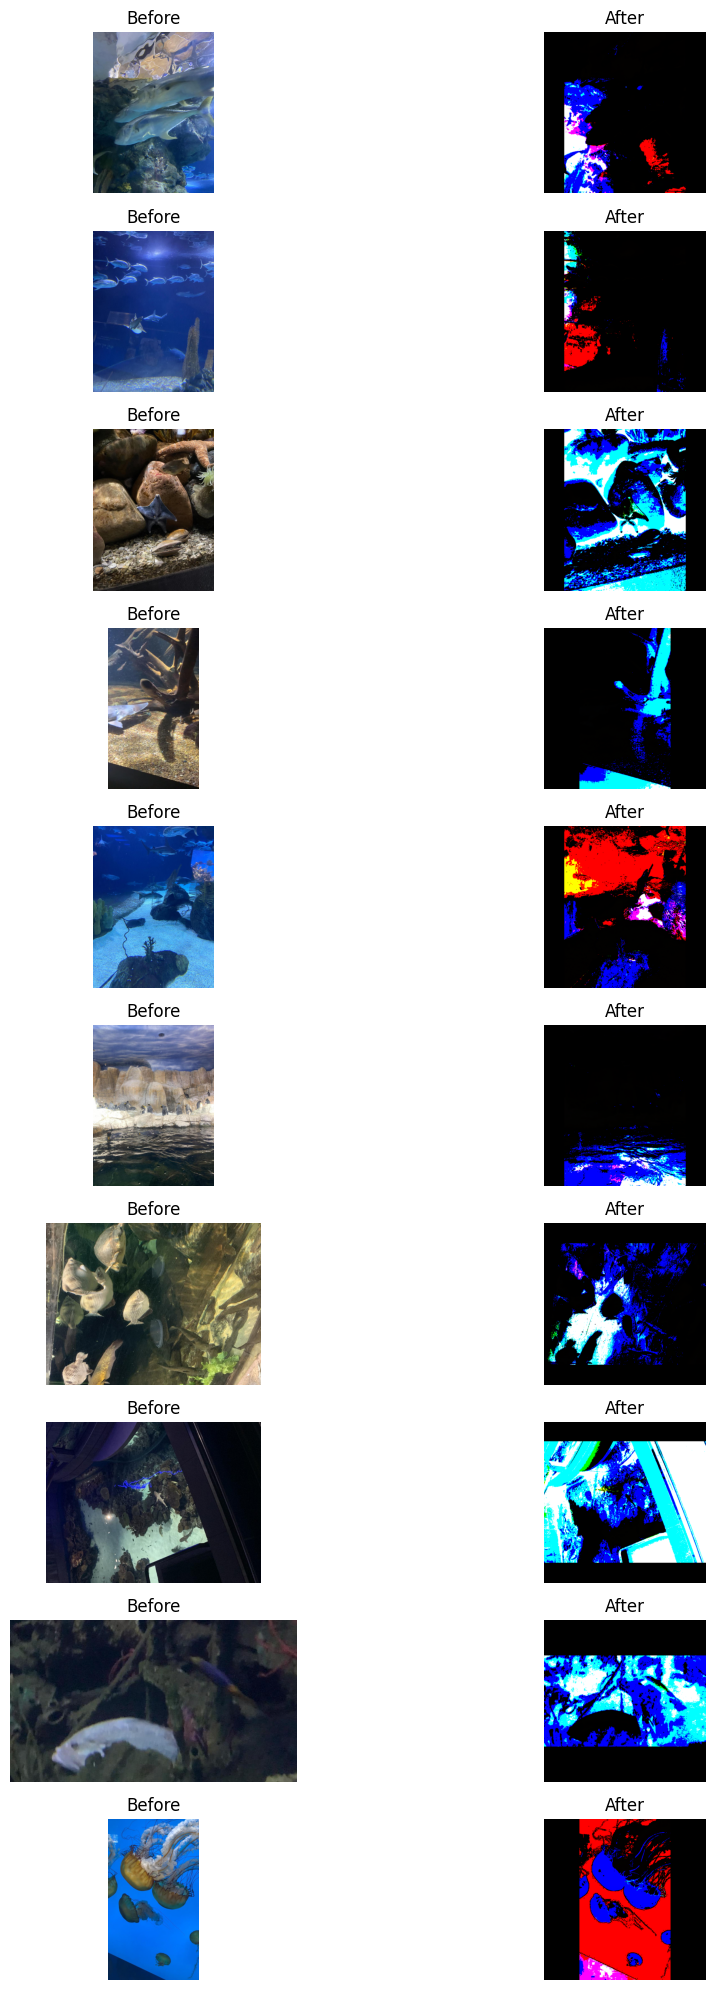

In [18]:
# Showing images before and after preprocessing
sample_files = random.sample(image_files, min(10, len(image_files)))

processed_images, processed_names = processing(sample_files,target_size=(640, 640))
processed_dict = dict(zip(processed_names, processed_images))

plt.figure(figsize=(12, 20))

for i, fname in enumerate(sample_files):
    original = Image.open(os.path.join(IMG_DIR, fname)).convert("RGB")
    original = np.array(original)

    processed = processed_dict[fname]

    plt.subplot(10, 2, 2*i + 1)
    plt.imshow(original)
    plt.title("Before")
    plt.axis("off")

    plt.subplot(10, 2, 2*i + 2)
    plt.imshow(processed.astype(np.uint8))
    plt.title("After")
    plt.axis("off")

plt.tight_layout()
plt.show()
